In [1]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print("x_train.shape: ", X_train.shape)
print("y_train.shape: ", y_train.shape)
print("x_test_val.shape: ", X_test.shape)


I0000 00:00:1787293341.634013   28526 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2035s 12us/step
x_train.shape:  (50000, 32, 32, 3)
y_train.shape:  (50000, 1)
x_test_val.shape:  (10000, 32, 32, 3)


In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

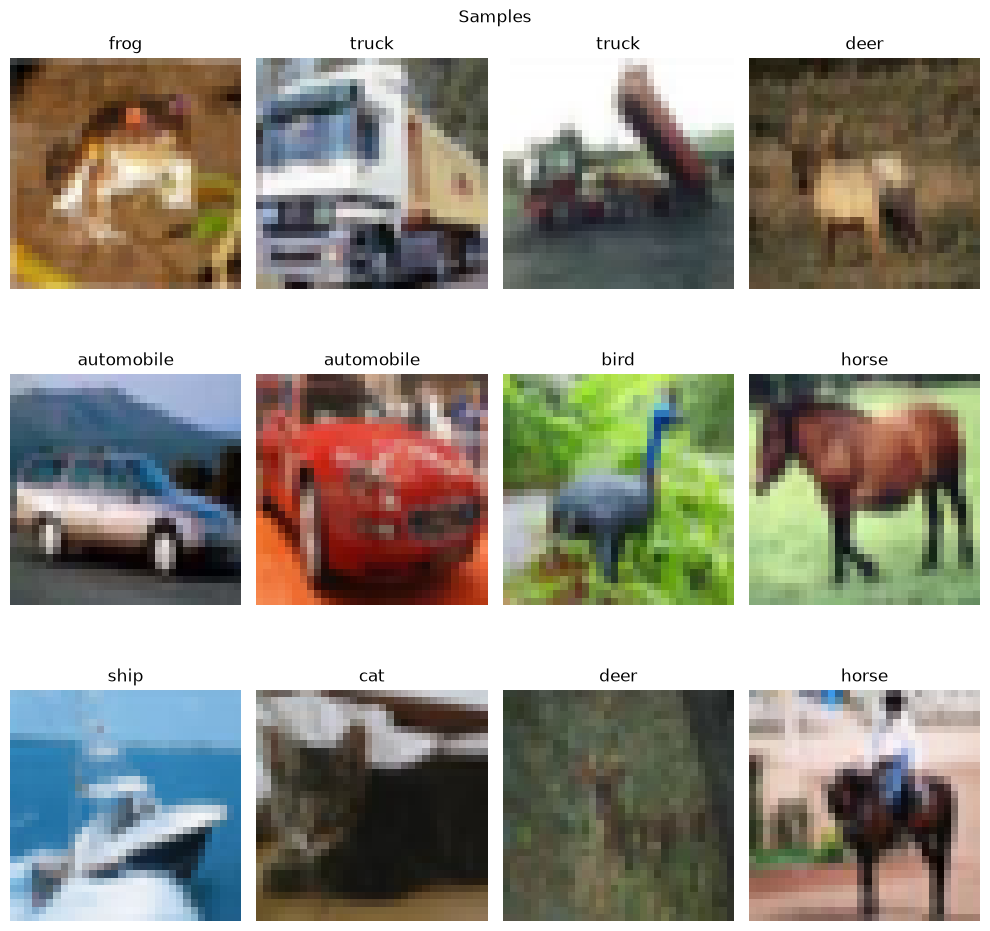

In [3]:
import matplotlib.pyplot as plt

def show_samples(data, labels):
    fig, axes = plt.subplots(3, 4, figsize=(10, 10))

    axes = axes.flatten()

    for i in range(len(axes)):
        axes[i].imshow(data[i])
        class_index=labels[i][0]
        class_name=class_names[class_index]
        axes[i].set_title(class_name)
        axes[i].axis('off')
    plt.tight_layout()
    fig.suptitle("Samples")
    plt.show()
show_samples(X_train, y_train)


In [4]:
#

In [5]:
import random
import numpy as np
import tensorflow as tf
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

In [6]:
X_train=X_train/255.0
X_test=X_test/255.0

In [7]:

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
model = Sequential()
model.add(Input(shape=(32, 32, 3)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'  ))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), activation='relu' ))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

epochs = 40
batch_size=128
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))


Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.4183 - loss: 1.5850 - val_accuracy: 0.5628 - val_loss: 1.2259
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6025 - loss: 1.1186 - val_accuracy: 0.6771 - val_loss: 0.9150
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6776 - loss: 0.9129 - val_accuracy: 0.7213 - val_loss: 0.7987
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7201 - loss: 0.8012 - val_accuracy: 0.7407 - val_loss: 0.7421
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7464 - loss: 0.7216 - val_accuracy: 0.7598 - val_loss: 0.7014
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7652 - loss: 0.6671 - val_accuracy: 0.7597 - val_loss: 0.7106
Epoch 7/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7825 - loss: 0.6180 - val_accuracy: 0.7631 - val_loss: 0.7005
Epoch 8/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7968 - loss: 0.5786 - val_accurac

In [8]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
print("Train Accuracy:", round(100*train_accuracy[-1],2))
print("Validation Accuracy:", round(100*val_accuracy[-1],2))

Train Accuracy: 93.32
Validation Accuracy: 80.84


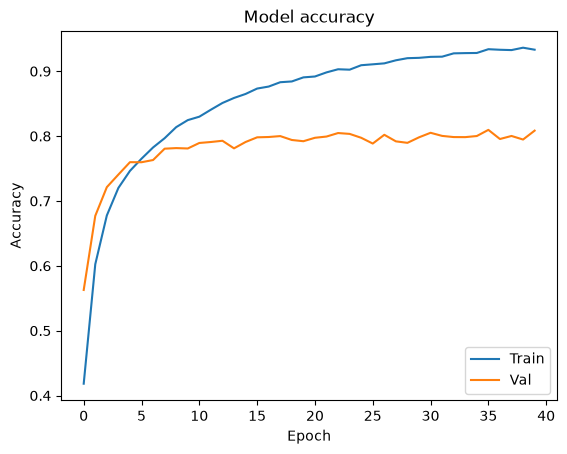

In [9]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


[[Text(0.5, 0, 'airplane'),
  Text(1.5, 0, 'automobile'),
  Text(2.5, 0, 'bird'),
  Text(3.5, 0, 'cat'),
  Text(4.5, 0, 'deer'),
  Text(5.5, 0, 'dog'),
  Text(6.5, 0, 'frog'),
  Text(7.5, 0, 'horse'),
  Text(8.5, 0, 'ship'),
  Text(9.5, 0, 'truck')],
 [Text(0, 0.5, 'airplane'),
  Text(0, 1.5, 'automobile'),
  Text(0, 2.5, 'bird'),
  Text(0, 3.5, 'cat'),
  Text(0, 4.5, 'deer'),
  Text(0, 5.5, 'dog'),
  Text(0, 6.5, 'frog'),
  Text(0, 7.5, 'horse'),
  Text(0, 8.5, 'ship'),
  Text(0, 9.5, 'truck')]]

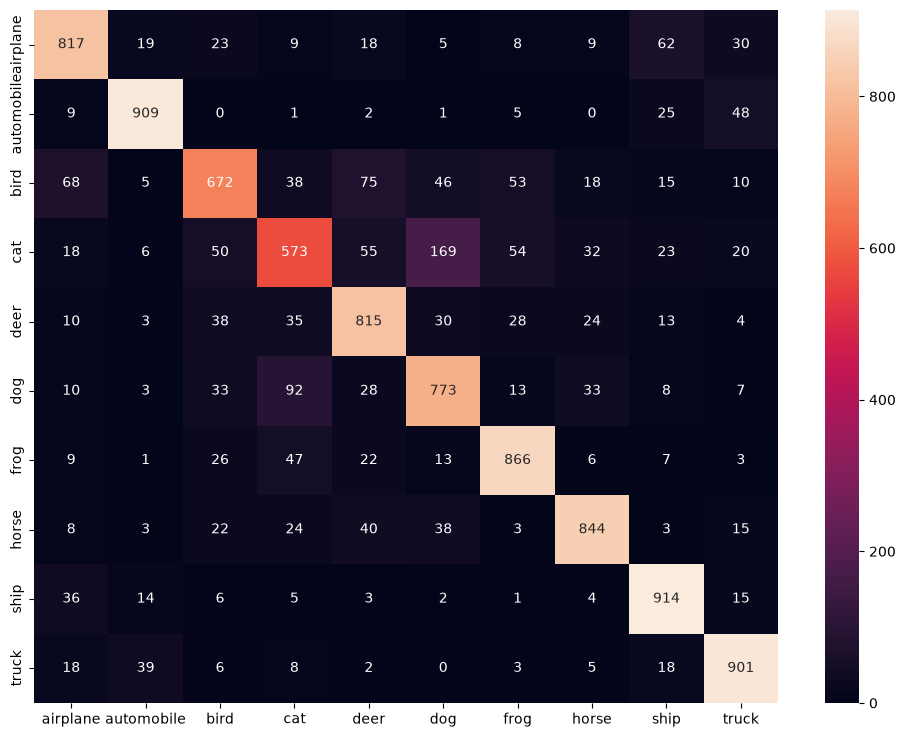

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
class_names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
predictions=model.predict(X_test)
y_pred_classes = np.argmax(predictions, axis=1)
confusion_mtx = tf.math.confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12, 9))
c = sns.heatmap(confusion_mtx, annot=True, fmt='g')
c.set(xticklabels=class_names, yticklabels=class_names)